# Forest Cover Type Classification Using Deep Learning on Cartographic Data

# Project Goals

* Develop a multi-class classification model to accurately predict forest cover types using cartographic variables.
* Apply deep learning techniques with TensorFlow and Keras to model complex ecological patterns in the dataset.
* Perform data preprocessing and exploratory data analysis (EDA) to understand feature distributions and relationships.
* Improve model performance through hyperparameter tuning, including adjustments to learning rate, batch size, network architecture, and regularization methods.
* Evaluate model effectiveness using performance metrics such as accuracy, classification report, and confusion matrix.
* Analyze misclassifications to understand model limitations and ecological similarities between classes.
* Build a clean, modular, and reproducible machine learning pipeline suitable for real-world applications and portfolio presentation.

# 1. Preprocessing & EDA

(581012, 55)
Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1',
       'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4',
       'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5',
       'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10',
       'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14',
       'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18',
       'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22',
       'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26',
       'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30',
       'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34',
       'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38',
       'Soil_Type39',

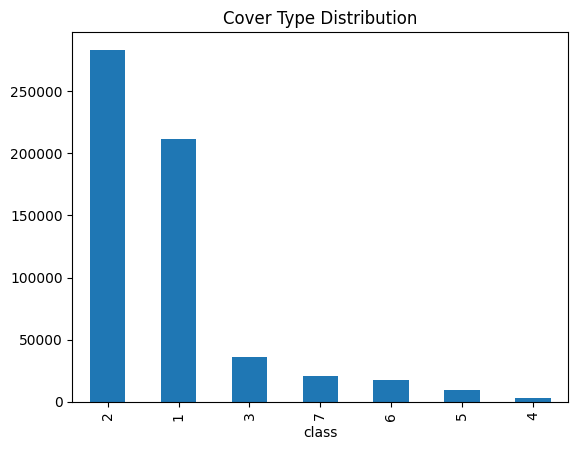

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("data/cover_data.csv")

print(df.shape)
df.head()

df.describe()

print(df.columns)

# Checking class distribution
df["class"].value_counts().plot(kind="bar")
plt.title("Cover Type Distribution")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Correct target column
X = df.drop("class", axis=1)
y = df["class"]

# making  labels start from 0
y = y - 1

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Spliting
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)

(406708, 54) (87152, 54) (87152, 54)


# 2. Model Building

In [3]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.4/200.4 MB 13.1 MB/s  0:00:15m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 19.0 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.9/676.9 kB 11.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 16.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 8.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 9.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 16.2 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24/24 [tensorflow]4 [tensorflow]]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))

model.add(Dense(7, activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/Users/macbookprom116gb/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/macbookprom116gb/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         7,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,607 (68.78 KB)

 Trainable params: 17,607 (68.78 KB)

 Non-trainable params: 0 (0.00 B)

# 3. Training

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
6355/6355 ━━━━━━━━━━━━━━━━━━━━ 5s 728us/step - accuracy: 0.6898 - loss: 0.7383 - val_accuracy: 0.7641 - val_loss: 0.5352
Epoch 2/50
6355/6355 ━━━━━━━━━━━━━━━━━━━━ 5s 766us/step - accuracy: 0.7583 - loss: 0.5633 - val_accuracy: 0.7875 - val_loss: 0.4887
Epoch 3/50
6355/6355 ━━━━━━━━━━━━━━━━━━━━ 5s 760us/step - accuracy: 0.7737 - loss: 0.5291 - val_accuracy: 0.7980 - val_loss: 0.4663
Epoch 4/50
6355/6355 ━━━━━━━━━━━━━━━━━━━━ 5s 714us/step - accuracy: 0.7828 - loss: 0.5100 - val_accuracy: 0.8111 - val_loss: 0.4432
Epoch 5/50
6355/6355 ━━━━━━━━━━━━━━━━━━━━ 4s 705us/step - accuracy: 0.7889 - loss: 0.4955 - val_accuracy: 0.8159 - val_loss: 0.4332
Epoch 6/50
6355/6355 ━━━━━━━━━━━━━━━━━━━━ 5s 715us/step - accuracy: 0.7942 - loss: 0.4882 - val_accuracy: 0.8212 - val_loss: 0.4239
Epoch 7/50
6355/6355 ━━━━━━━━━━━━━━━━━━━━ 5s 755us/step - accuracy: 0.7979 - loss: 0.4799 - val_accuracy: 0.8261 - val_loss: 0.4188
Epoch 8/50
6355/6355 ━━━━━━━━━━━━━━━━━━━━ 5s 759us/step - accuracy: 0.7997 -

# 4. Evaluation

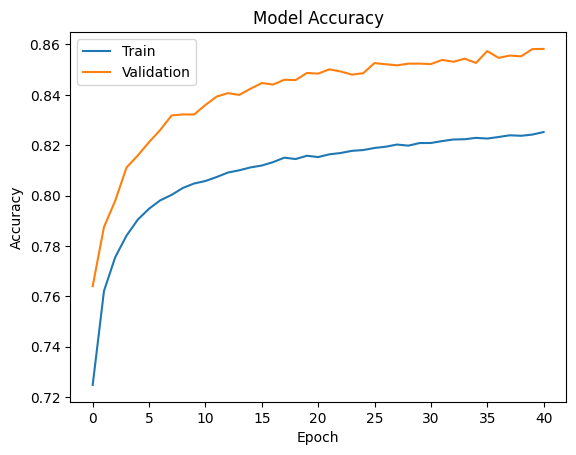

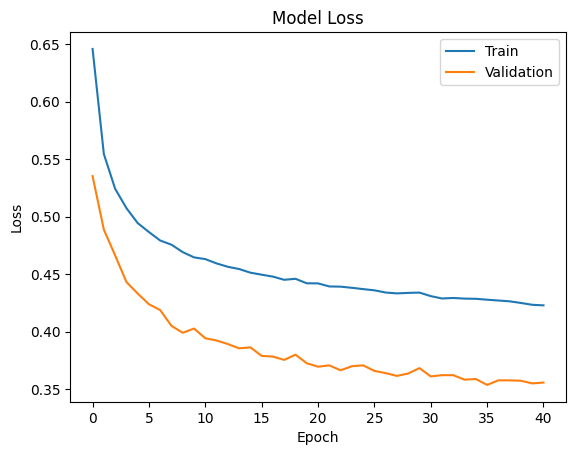

In [11]:
# Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

The training and validation accuracy curves show a steady improvement over epochs, indicating that the model is successfully learning meaningful patterns from the data. Training accuracy increases from approximately 0.72 to 0.83, while validation accuracy improves from around 0.76 to 0.86.

Interestingly, the validation accuracy is consistently higher than the training accuracy. This is likely due to the use of dropout regularization, which makes training more challenging but improves generalization performance on unseen data.

The loss curves show a smooth and consistent decrease for both training and validation sets. Validation loss decreases slightly faster and remains lower than training loss, further suggesting that the model is not overfitting and generalizes well.

Overall, the model demonstrates good convergence, with performance stabilizing after around 30–40 epochs. Early stopping could be applied to reduce training time without sacrificing performance.

# Confusion Matrix

2724/2724 ━━━━━━━━━━━━━━━━━━━━ 1s 254us/step
              precision    recall  f1-score   support

           0       0.89      0.82      0.85     31659
           1       0.85      0.93      0.89     42664
           2       0.83      0.83      0.83      5297
           3       0.93      0.46      0.62       394
           4       0.82      0.41      0.55      1493
           5       0.67      0.68      0.68      2591
           6       0.91      0.79      0.84      3054

    accuracy                           0.86     87152
   macro avg       0.84      0.70      0.75     87152
weighted avg       0.86      0.86      0.86     87152



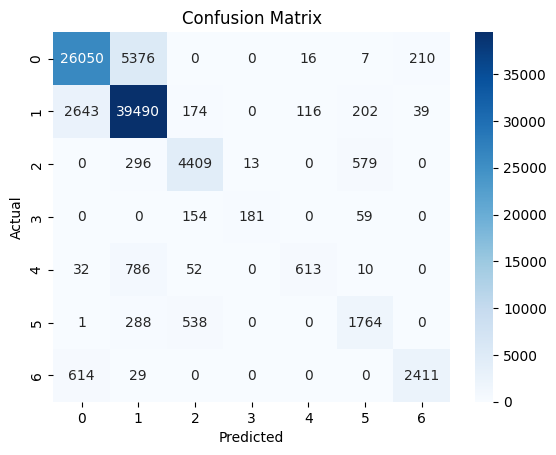

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

preds = model.predict(X_test)
preds = np.argmax(preds, axis=1)

print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The model achieves an overall accuracy of approximately 86%, indicating strong performance on this multi-class classification task.

From the classification report:

Classes 0 and 1 have high precision and recall (around 0.85–0.93), meaning they are well learned by the model.
Classes 2 and 6 also perform reasonably well with balanced precision and recall.
However, classes 3 and 4 show significantly lower recall (around 0.46 and 0.41), indicating that many samples from these classes are misclassified.

The confusion matrix reveals where these errors occur:

A large number of class 0 samples are misclassified as class 1, showing overlap between these two categories.
Class 4 is frequently predicted as class 1, suggesting that these classes share similar feature patterns.
Class 3 has very few correct predictions, likely due to its small sample size (class imbalance).

These misclassifications are expected in ecological datasets, where different forest types can share similar environmental characteristics such as elevation, soil type, and slope.

# Conclusion 

This project successfully applied deep learning techniques to classify forest cover types using cartographic data. A fully connected neural network was developed using TensorFlow and Keras, achieving an overall accuracy of approximately 86%, demonstrating strong predictive capability for a multi-class classification problem.

The model showed good generalization, as indicated by the close alignment between training and validation performance and the absence of significant overfitting. Performance was particularly strong for the dominant classes, while lower accuracy on minority classes highlighted the impact of class imbalance and overlapping environmental features.

Analysis of the confusion matrix revealed that certain forest types were frequently misclassified due to similarities in terrain and ecological conditions, which is expected in real-world environmental data. Despite these challenges, the model effectively captured key patterns in the dataset.

Future improvements could include applying class balancing techniques, exploring more advanced models, and conducting further hyperparameter tuning to enhance performance on underrepresented classes.

Overall, this project demonstrates the effectiveness of deep learning in environmental classification tasks and highlights the importance of both model evaluation and domain-specific interpretation of results.